# Machine Learning Assignment 2: Applying ML Algorithms
Mohammed R. Awad // ID: 1320225023

## 1. Import Libraries

In [25]:
import warnings
warnings.filterwarnings('ignore')

#data manipulation
import numpy as np
import pandas as pd

#visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Scikit-learn: preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Scikit-learn: regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Scikit-learn: classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
#Scikit-learn: clustering /dimensionality reduction
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Load and Inspect the Dataset

sep='\t' is used when reading it cuz the actual columns inside the file are separated by tabs

In [26]:
# Load dataset
df = pd.read_csv("data/marketing_campaign.csv", sep='\t')

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [27]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [28]:
# Check missing values
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Income    24
dtype: int64

In [29]:
# Basic statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


## 3. Data Preprocessing and Feature Engineering

preprocessing steps:

- fill missing Income values using median imputation.
- create Age from Year_Birth
- create TotalSpending by summing all spending columns
- create TotalChildren by summing Kidhome and Teenhome
- remove unrealistic ages under 18 or over 100.
- remove zero-income rows
- encode Education
- prepare Marital_Status for one-hot encoding later

For supervised learning, one-hot encoding and scaling are fitted on the training data

In [30]:
# Spending columns used to create TotalSpending
spending_cols = [
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
]
# apply the required cleaning and feature engineering steps
def preprocess_data(data):
    df_clean = data.copy()

    # 1. Handle missing Income values using median imputation
    income_median = df_clean['Income'].median()
    df_clean['Income'] = df_clean['Income'].fillna(income_median)

    # 2. Create Age from Year_Birth
    #age was calculated using the year 2014 as dataset year
    current_year = 2014
    df_clean['Age'] = current_year - df_clean['Year_Birth']

    # 3. Create TotalSpending
    df_clean['TotalSpending'] = df_clean[spending_cols].sum(axis=1)

    # 4. Create TotalChildren
    df_clean['TotalChildren'] = df_clean['Kidhome'] + df_clean['Teenhome']

    # 5. Remove unrealistic ages and zero-income rows
    df_clean = df_clean[(df_clean['Age'] >= 18) & (df_clean['Age'] <= 100)]
    df_clean = df_clean[df_clean['Income'] > 0]

    # 6. Label encode Education using a simple ordered mapping
    #2n Cycle in education was encoded as level 1 between Basic and Graduation
    education_map = {
        'Basic': 0,
        '2n Cycle': 1,
        'Graduation': 2,
        'Master': 3,
        'PhD': 4
    }
    df_clean['Education_Encoded'] = df_clean['Education'].map(education_map)

    return df_clean

# Apply preprocessing
df_clean = preprocess_data(df)

print('Original shape:', df.shape)
print('Cleaned shape:', df_clean.shape)
print('Rows removed:', df.shape[0] - df_clean.shape[0])
print('Missing values after preprocessing:', df_clean.isnull().sum().sum())

df_clean[['Year_Birth', 'Age', 'Income', 'TotalSpending', 'TotalChildren', 'Education', 'Education_Encoded']].head()

Original shape: (2240, 29)
Cleaned shape: (2237, 33)
Rows removed: 3
Missing values after preprocessing: 0


,Year_Birth,Age,Income,TotalSpending,TotalChildren,Education,Education_Encoded
0,1957,57,58138.0,1617,0,Graduation,2
1,1954,60,46344.0,27,2,Graduation,2
2,1965,49,71613.0,776,0,Graduation,2
3,1984,30,26646.0,53,1,Graduation,2
4,1981,33,58293.0,422,1,PhD,4


In [31]:
# Check the range after filtering
print('Age range after filtering:', df_clean['Age'].min(), 'to', df_clean['Age'].max())
print('Income range after filtering:', df_clean['Income'].min(), 'to', df_clean['Income'].max())

Age range after filtering: 18 to 74
Income range after filtering: 1730.0 to 666666.0


In [32]:
# Show the top 4 marital status categories before one-hot encoding
# Other categories will be grouped as Other during supervised feature preparation.
df_clean['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

## 4. EDA

visualizations to help understand the customer data before model training

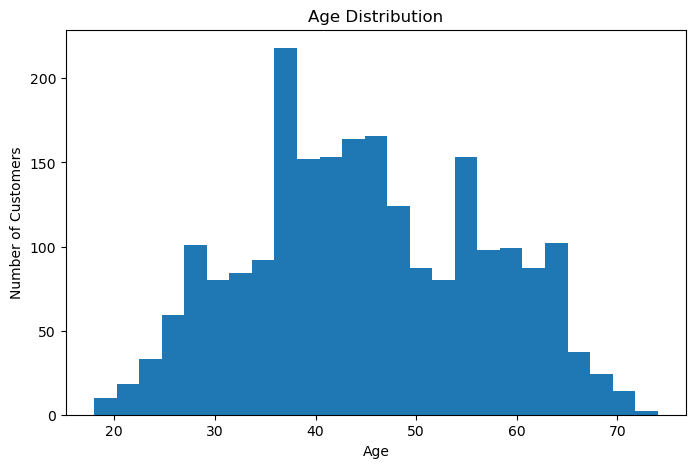

In [33]:
#age distribution
plt.figure(figsize=(8, 5))
plt.hist(df_clean['Age'], bins=25)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

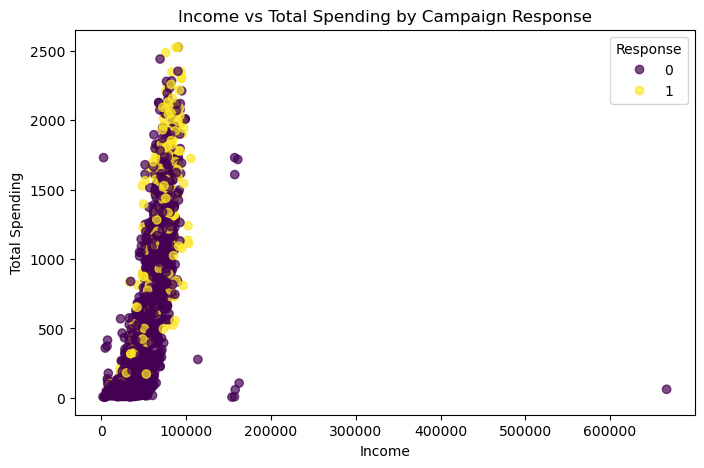

In [34]:
#Income vs TotalSpending
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df_clean['Income'], df_clean['TotalSpending'], c=df_clean['Response'], alpha=0.7)
plt.legend(*scatter.legend_elements(), title='Response')
plt.title('Income vs Total Spending by Campaign Response')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.show()

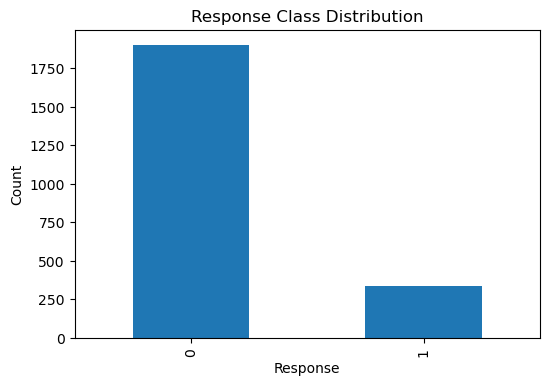

Response
0    1903
1     334
Name: count, dtype: int64
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


In [35]:
# class distribution for Response
plt.figure(figsize=(6, 4))
df_clean['Response'].value_counts().sort_index().plot(kind='bar')
plt.title('Response Class Distribution')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()

print(df_clean['Response'].value_counts())
print(df_clean['Response'].value_counts(normalize=True).round(3))

### EDA Finding

The Response target is imbalanced. Most customers did not accept the last campaign. This is important for classification because accuracy alone can be misleading. Recall and F1-score are important because the positive class (Response = 1) is the smaller and more important group.

In [36]:
#group marital status using top 4 categories from training data then one-hot encode
def encode_marital_status_train_test(X_train, X_test, column='Marital_Status'):
    X_train_encoded = X_train.copy()
    X_test_encoded = X_test.copy()

    # Get top 4 categories from training data only
    top_4 = X_train_encoded[column].value_counts().head(4).index.tolist()

    # Group rare categories as Other
    X_train_encoded[column] = X_train_encoded[column].where(
        X_train_encoded[column].isin(top_4), 'Other'
    )
    X_test_encoded[column] = X_test_encoded[column].where(
        X_test_encoded[column].isin(top_4), 'Other'
    )

    # One-hot encode using pandas get_dummies
    X_train_encoded = pd.get_dummies(X_train_encoded, columns=[column], drop_first=True, dtype=int)
    X_test_encoded = pd.get_dummies(X_test_encoded, columns=[column], drop_first=True, dtype=int)

    # Align columns so train and test have the same dummy columns
    X_train_encoded, X_test_encoded = X_train_encoded.align(
        X_test_encoded, join='left', axis=1, fill_value=0
    )

    return X_train_encoded, X_test_encoded

## 6. Supervised Learning with Regression

Target variable: TotalSpending

Required models:

- Linear regression
- Ridge regression with alpha=1.0
- Decision tree regressor with max_depth=5

Required evaluation metrics:

- MSE
- RMSE
- R2 Score

spending component columns are not used as input features because TotalSpending is calculated from them. Using them would create data leakage.

In [37]:
# Regression feature columns
regression_features = [
    'Income', 'Age', 'TotalChildren', 'Recency', 'Education_Encoded',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5', 'Complain',
    'Marital_Status'
]

X_reg = df_clean[regression_features]
y_reg = df_clean['TotalSpending']

# 80/20 train/test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# One-hot encode Marital_Status using training data only
X_train_reg_encoded, X_test_reg_encoded = encode_marital_status_train_test(
    X_train_reg, X_test_reg, column='Marital_Status'
)

# Scale features using StandardScaler fitted on the training data only
reg_scaler = StandardScaler()
X_train_reg_scaled = reg_scaler.fit_transform(X_train_reg_encoded)
X_test_reg_scaled = reg_scaler.transform(X_test_reg_encoded)

print('Training shape:', X_train_reg_scaled.shape)
print('Testing shape:', X_test_reg_scaled.shape)

Training shape: (1789, 20)
Testing shape: (448, 20)


In [38]:
# Train and evaluate regression models
regression_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=5, random_state=42)
}

regression_results = []

for model_name, model in regression_models.items():
    # Train model
    model.fit(X_train_reg_scaled, y_train_reg)

    # Predict on test data
    y_pred = model.predict(X_test_reg_scaled)

    # Evaluate model
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred)

    regression_results.append({
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

# Comparison table
regression_results_df = pd.DataFrame(regression_results)
regression_results_df

,Model,MSE,RMSE,R2 Score
0,Linear Regression,69881.762235,264.351588,0.816040
1,Ridge Regression,69873.322720,264.335625,0.816062
2,Decision Tree Regressor,58480.443341,241.827301,0.846053


### Regression Interpretation

Ridge regression is included because it is a regularized version of Linear Regression. It can reduce overfitting by shrinking large coefficients while keeping the model simple.

The best regression model is the one with the lowest RMSE and highest R2 Score in the comparison table.

## 7. Supervised Learning with Classification

Target variable: Response

the models:

- logistic Regression with class_weight='balanced
- K-Nearest Neighbors with n_neighbors=5
- random Forest Classifier with n_estimators=100

required evaluation metrics:

- accuracy
- precision
- recall
- f1-Score
- confusion Matrix
- classification report and confusion matrix

In [39]:
# Show class distribution before model training
class_distribution = df_clean['Response'].value_counts()
class_distribution_percentage = df_clean['Response'].value_counts(normalize=True).round(3)

print('Class distribution:')
print(class_distribution)
print()
print('Class distribution percentage:')
print(class_distribution_percentage)

Class distribution:
Response
0    1903
1     334
Name: count, dtype: int64

Class distribution percentage:
Response
0    0.851
1    0.149
Name: proportion, dtype: float64


In [40]:
# Classification feature columns
# TotalSpending is included because it can help predict campaign response.
classification_features = [
    'Income', 'Age', 'TotalChildren', 'TotalSpending', 'Recency', 'Education_Encoded',
    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5', 'Complain',
    'Marital_Status'
]

X_clf = df_clean[classification_features]
y_clf = df_clean['Response']

# Stratify keeps the imbalanced class proportions similar in train and test sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# One-hot encode Marital_Status using training data only
X_train_clf_encoded, X_test_clf_encoded = encode_marital_status_train_test(
    X_train_clf, X_test_clf, column='Marital_Status'
)

# Scale features for Logistic Regression and KNN
clf_scaler = StandardScaler()
X_train_clf_scaled = clf_scaler.fit_transform(X_train_clf_encoded)
X_test_clf_scaled = clf_scaler.transform(X_test_clf_encoded)

print('Training shape:', X_train_clf_encoded.shape)
print('Testing shape:', X_test_clf_encoded.shape)

Training shape: (1789, 21)
Testing shape: (448, 21)


In [41]:
# define classification models
classification_models = {
    'Logistic Regression': {
        'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        'X_train': X_train_clf_scaled,
        'X_test': X_test_clf_scaled
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(n_neighbors=5),
        'X_train': X_train_clf_scaled,
        'X_test': X_test_clf_scaled
    },
    'Random Forest Classifier': {
        'model': RandomForestClassifier(n_estimators=100, random_state=42),
        'X_train': X_train_clf_encoded,
        'X_test': X_test_clf_encoded
    }
}

classification_results = []

for model_name, item in classification_models.items():
    model = item['model']
    X_train_model = item['X_train']
    X_test_model = item['X_test']

    # train model
    model.fit(X_train_model, y_train_clf)

    # predict
    y_pred = model.predict(X_test_model)

    # full classification report (required by the assignment)
    print(f'\n===== {model_name} =====')
    print(classification_report(y_test_clf, y_pred, zero_division=0))
    # store metrics
    classification_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_clf, y_pred),
        'Precision': precision_score(y_test_clf, y_pred, zero_division=0),
        'Recall': recall_score(y_test_clf, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_clf, y_pred, zero_division=0)
    })

# Summary comparison table
classification_results_df = pd.DataFrame(classification_results)
classification_results_df


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.96      0.81      0.87       381
           1       0.42      0.79      0.55        67

    accuracy                           0.80       448
   macro avg       0.69      0.80      0.71       448
weighted avg       0.88      0.80      0.83       448


===== K-Nearest Neighbors =====
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       381
           1       0.58      0.28      0.38        67

    accuracy                           0.86       448
   macro avg       0.73      0.62      0.65       448
weighted avg       0.84      0.86      0.84       448


===== Random Forest Classifier =====
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       381
           1       0.66      0.31      0.42        67

    accuracy                           0.87       448
   macro avg       0.77 

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.803571,0.417323,0.791045,0.546392
1,K-Nearest Neighbors,0.861607,0.575758,0.283582,0.380000
2,Random Forest Classifier,0.872768,0.656250,0.313433,0.424242


### Which metric matters most here and why?

The Response classes are imbalanced about 85% are 0 (did not accept) and only 15% are 1 (accepted the campaign). This imbalance is what determines which metric we should trust.
Accuracy is misleading and should not be the main metric. A model that simply predicts "0" for every customer would still score ~85% accuracy while finding zero actual responders. High accuracy here can hide a completely useless model, so we look past it.
Because missing a real responder is more costly than wasting a contact, recall for class 1 is important it tells us what fraction of true responders the model actually catches. But maximizing recall alone is a trap: a model can flag almost everyone as a responder, getting high recall while flooding non-responders with irrelevant offers (low precision).
The single most important metric here is the F1-score for class 1. F1 is the harmonic mean of precision and recall, so it rewards a model only when it catches real responders and keeps false alarms low. It is robust to the class imbalance in this dataset, which is exactly why it's the right metric to compare our three classifiers on, rather than accuracy.



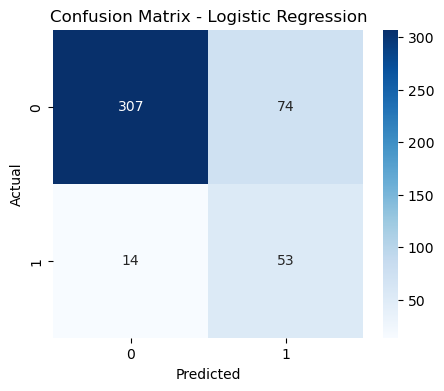

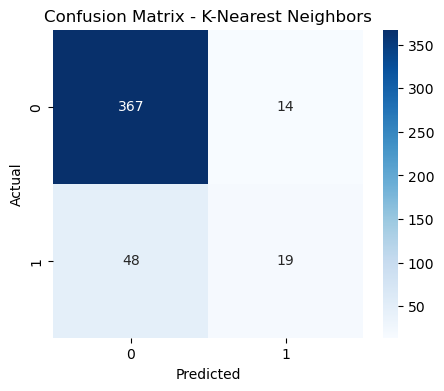

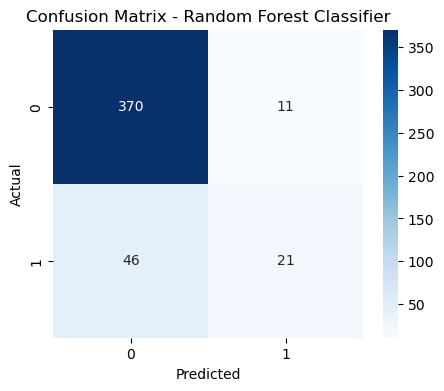

In [42]:
# Visualize confusion matrices for each classification model
for model_name, item in classification_models.items():
    model = item['model']
    X_test_model = item['X_test']
    y_pred = model.predict(X_test_model)

    cm = confusion_matrix(y_test_clf, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['0', '1'], yticklabels=['0', '1'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 8. Unsupervised Learning - Clustering

Goal: segment customers using the required four features:

- TotalSpending
- Income
- Age
- TotalChildren

The features are scaled using StandardScaler. Then K-Means is applied, and PCA is used only for 2D visualization.

In [43]:
# Select required clustering features
cluster_features = ['TotalSpending', 'Income', 'Age', 'TotalChildren']
X_cluster = df_clean[cluster_features]

# Scale the clustering features
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print('Clustering data shape:', X_cluster_scaled.shape)

Clustering data shape: (2237, 4)


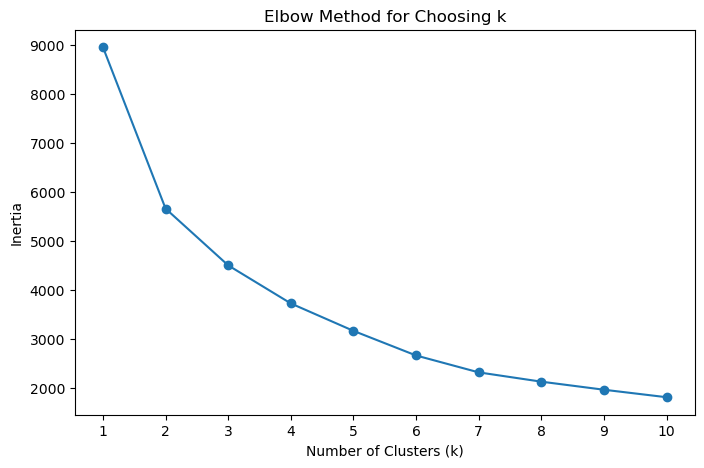

,k,Inertia
0,1,8948.000000
1,2,5659.744288
2,3,4503.670411
3,4,3728.362277
4,5,3169.394874
5,6,2667.884018
6,7,2323.842339
7,8,2134.399466
8,9,1970.185599
9,10,1817.649740


In [44]:
# Elbow Method: inertia vs k from 1 to 10
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method for Choosing k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()

pd.DataFrame({'k': list(k_values), 'Inertia': inertias})

### Choice of k

Based on the elbow curve the decrease in inertia becomes slower after around **k = 4** therefore, k=4 is selected for customer segmentation but after k=4 the improvement becomes smaller this indicates that 4 clusters provide a good balance between model performance and simplicity also gives meaningful customer segments based on Income, TotalSpending, Age, and TotalChildren.

In [45]:
# Fit K-Means with the chosen k
chosen_k = 4
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
df_clustered = df_clean.copy()
df_clustered['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Show number of customers in each cluster
df_clustered['Cluster'].value_counts().sort_index()

Cluster
0    458
1    584
2    463
3    732
Name: count, dtype: int64

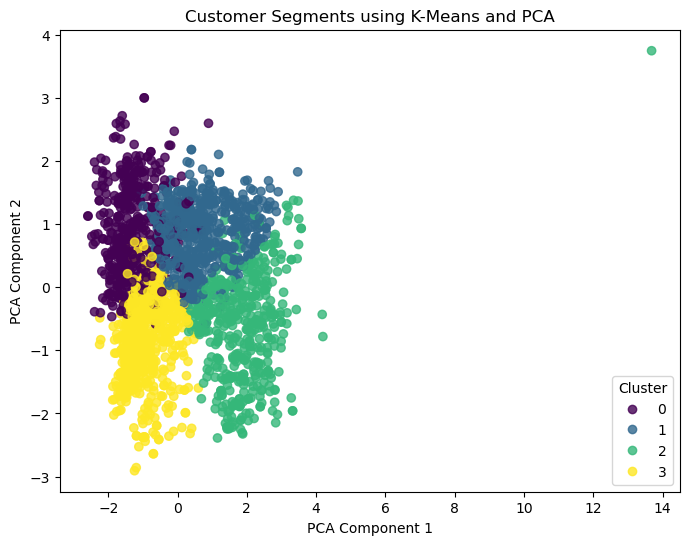

In [46]:
# PCA reduction to 2 components for visualization
pca = PCA(n_components=2)
cluster_pca = pca.fit_transform(X_cluster_scaled)

df_clustered['PCA1'] = cluster_pca[:, 0]
df_clustered['PCA2'] = cluster_pca[:, 1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_clustered['PCA1'], df_clustered['PCA2'], c=df_clustered['Cluster'], alpha=0.8)
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.title('Customer Segments using K-Means and PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [47]:
# Cluster profiling: mean values of the required features
cluster_profile = df_clustered.groupby('Cluster')[cluster_features].mean().round(2)
cluster_profile

,TotalSpending,Income,Age,TotalChildren
Cluster,,,,
0,222.81,44108.53,48.59,2.12
1,802.91,61336.05,57.14,0.69
2,1434.79,78094.85,39.50,0.29
3,163.65,33678.73,36.85,0.85


In [48]:
# Add simple written descriptions for each segment based on the profile table
overall = df_clustered[cluster_features].mean()

for cluster_id, row in cluster_profile.iterrows():
    income_level   = 'high-income'  if row['Income'] >= overall['Income'] else 'lower-income'
    spending_level = 'high-spending' if row['TotalSpending'] >= overall['TotalSpending'] else 'lower-spending'
    age_level      = 'older' if row['Age'] >= overall['Age'] else 'younger'
    children_level = 'with more children' if row['TotalChildren'] >= overall['TotalChildren'] else 'with fewer children'

    print(f'Cluster {cluster_id}: {income_level}, {spending_level}, {age_level} customers, {children_level}.')

Cluster 0: lower-income, lower-spending, older customers, with more children.
Cluster 1: high-income, high-spending, older customers, with fewer children.
Cluster 2: high-income, high-spending, younger customers, with fewer children.
Cluster 3: lower-income, lower-spending, younger customers, with fewer children.
